# CSCN8020 Assignment 1 - Reinforcement Learning Programming

**Student:** Abdalla Mohamed  
**Student ID:** 9089339  
**Work mode:** Individual assignment

This notebook contains all four required problems in one runnable notebook. It uses object-oriented design, logging, Markdown theory, mathematical explanation, code implementation, output tables, and comparisons.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.environments import GridWorldEnvironment, make_assignment_gridworld
from src.agents import ValueIterationAgent, InPlaceValueIterationAgent, OffPolicyMonteCarloAgent
from src.utils import setup_logger, print_grid, arrow

setup_logger("logs/sample_execution.log")
GAMMA = 0.9
print("Setup complete. Gamma =", GAMMA)

Matplotlib is building the font cache; this may take a moment.


Setup complete. Gamma = 0.9


## Problem 1 - Pick-and-Place Robot MDP Design

### MDP Design

A pick-and-place robot can be modelled as a Markov Decision Process because the next robot condition depends on the current robot condition and the motor command selected by the agent.

**State space S:** A state should include the information needed to make the next control decision:

- Joint positions: shoulder, elbow, wrist, gripper joint angles.
- Joint velocities: angular velocity of each linkage.
- End-effector position and velocity relative to the object and target bin.
- Gripper status: open, closing, holding object, released.
- Object status: not grasped, grasped, placed successfully, dropped.

A compact continuous state example is:

$$s_t = [q_t, \dot{q}_t, x^{ee}_t, \dot{x}^{ee}_t, x^{object}_t, x^{target}, g_t]$$

**Action space A:** Since the robot must learn fast and smooth motor control directly, actions can be continuous motor commands:

- Joint torques or motor velocity commands for each actuator.
- Gripper open/close command.

An action example is:

$$a_t = [	au_1, 	au_2, 	au_3, 	au_4, a^{gripper}]$$

**Transition function P:** The transition is controlled by robot physics. After applying the selected motor command, the robot moves to a new state based on its mechanical dynamics, object contact, friction, and possible noise.

**Reward function R:** The reward should encourage speed, accuracy, smoothness, and safety:

$$R_t = r_{success} - c_1 d_{object} - c_2 d_{target} - c_3 ||a_t||^2 - c_4 ||a_t-a_{t-1}||^2 - c_5 I_{collision}$$

Possible reward terms:

- Large positive reward for successfully placing the object.
- Negative distance penalty when the gripper is far from the object or the object is far from the target.
- Small time penalty to encourage fast completion.
- Energy penalty for large motor commands.
- Smoothness penalty for sudden changes in motor commands.
- Large penalty for collision, dropping the object, or unsafe joint limits.

### Talking Points

**A. Key RL feature:** This problem is an MDP design problem. The most important feature is the state representation because the agent needs joint positions and velocities to satisfy the Markov property.

**B. Implementation/testing challenge:** The major challenge is reward design. A reward focused only on speed may cause unsafe or jerky movements, while a reward focused only on smoothness may make the robot too slow.

**C. Why this is RL:** This is Reinforcement Learning because an agent interacts with an environment, selects motor actions, receives rewards, and improves a policy over time. It is not supervised learning because there is no fixed label for every state. The agent learns from reward feedback and sequential consequences, matching Sutton and Barto's agent-environment framework.

## Problem 2 - 2x2 Gridworld Value Iteration

### Assumptions

State layout:

|       |       |
|---|---|
| s1 | s2 |
| s3 | s4 |

Actions are up, down, left, and right. Invalid actions keep the agent in the same state. The assignment gives rewards by state: R(s1)=5, R(s2)=10, R(s3)=1, R(s4)=2. I use gamma = 0.9.

Value iteration update:

$$V_{k+1}(s)=\max_a [R(s)+\gamma V_k(s')]$$

### Iteration 0 - Initial Value Function

$$V_0(s1)=0,\;V_0(s2)=0,\;V_0(s3)=0,\;V_0(s4)=0$$

### Iteration 1

Because all initial next-state values are zero:

$$V_1(s1)=5+0.9(0)=5$$
$$V_1(s2)=10+0.9(0)=10$$
$$V_1(s3)=1+0.9(0)=1$$
$$V_1(s4)=2+0.9(0)=2$$

Updated value function after Iteration 1:

| State | Value |
|---|---:|
| s1 | 5 |
| s2 | 10 |
| s3 | 1 |
| s4 | 2 |

### Iteration 2

Use the best next state from each state.

For s1, possible next values are s1=5, s2=10, s3=1, so max is 10:

$$V_2(s1)=5+0.9(10)=14$$

For s2, possible next values are s2=10, s1=5, s4=2, so max is 10:

$$V_2(s2)=10+0.9(10)=19$$

For s3, possible next values are s3=1, s1=5, s4=2, so max is 5:

$$V_2(s3)=1+0.9(5)=5.5$$

For s4, possible next values are s4=2, s2=10, s3=1, so max is 10:

$$V_2(s4)=2+0.9(10)=11$$

Value function after Iteration 2:

| State | Value |
|---|---:|
| s1 | 14.0 |
| s2 | 19.0 |
| s3 | 5.5 |
| s4 | 11.0 |

### Policy Improvement after Iteration 2

The greedy improved policy chooses the action that leads to the highest next value. For example, s1 chooses right because s2 has the highest value.

### Talking Points

**A. Key RL feature:** Value iteration combines policy evaluation and policy improvement through the Bellman optimality update.

**B. Implementation/testing challenge:** The main testing challenge is matching the manual calculations with the code, especially when invalid actions keep the agent in the same state.

**C. Why this is RL:** The solution uses states, actions, rewards, transitions, a value function, and a policy. The Bellman update comes directly from dynamic programming methods described by Sutton and Barto.

In [2]:
# Code verification for Problem 2
states = ["s1", "s2", "s3", "s4"]
rewards = {"s1": 5, "s2": 10, "s3": 1, "s4": 2}
transitions = {
    "s1": {"up": "s1", "down": "s3", "left": "s1", "right": "s2"},
    "s2": {"up": "s2", "down": "s4", "left": "s1", "right": "s2"},
    "s3": {"up": "s1", "down": "s3", "left": "s3", "right": "s4"},
    "s4": {"up": "s2", "down": "s4", "left": "s3", "right": "s4"},
}

V = {s: 0.0 for s in states}
history = [V.copy()]
for _ in range(2):
    V = {s: rewards[s] + GAMMA * max(V[transitions[s][a]] for a in transitions[s]) for s in states}
    history.append(V.copy())

pd.DataFrame(history, index=["V0", "V1", "V2"])

,s1,s2,s3,s4
V0,0.0,0.0,0.0,0.0
V1,5.0,10.0,1.0,2.0
V2,14.0,19.0,5.5,11.0


## Problem 3 - 5x5 Gridworld Value Iteration and In-Place Variation

The 5x5 gridworld uses row-column states such as s0,3. The goal state is s4,4. The grey states are s2,2, s3,0, and s0,4. The terminal reward is +10, grey-state reward is -5, and regular-state reward is assumed to be -1 because the uploaded table visually omits the regular reward value.

The standard value iteration implementation uses a separate copy of the value array for each full sweep. The in-place version updates one shared value table and immediately uses updated values in later states during the same sweep. Both apply the Bellman optimality update.

In [3]:
env = make_assignment_gridworld()
vi = ValueIterationAgent(env, gamma=GAMMA, theta=1e-8)
V_vi, pi_vi = vi.run()

inplace = InPlaceValueIterationAgent(env, gamma=GAMMA, theta=1e-8)
V_ip, pi_ip = inplace.run()

print("Synchronous VI value function:")
print_grid(env.values_as_grid(V_vi))
print("\nSynchronous VI policy:")
for row in env.policy_as_grid({s: arrow(a) for s, a in pi_vi.items()}):
    print(row)

print("\nIn-place VI value function:")
print_grid(env.values_as_grid(V_ip))
print("\nIn-place VI policy:")
for row in env.policy_as_grid({s: arrow(a) for s, a in pi_ip.items()}):
    print(row)

comparison = pd.DataFrame({
    "Method": ["Synchronous Value Iteration", "In-Place Value Iteration"],
    "Iterations": [vi.iterations, inplace.iterations],
    "Optimization Time Seconds": [vi.optimization_time, inplace.optimization_time],
    "Same Rounded Values As VI": [True, all(round(V_vi[s], 6) == round(V_ip[s], 6) for s in env.states)],
})
comparison

2026-06-12 13:50:21,653 | INFO | Starting synchronous value iteration: gamma=0.9 theta=1e-08


2026-06-12 13:50:21,656 | INFO | VI iteration=1 delta=10.0000000000


2026-06-12 13:50:21,657 | INFO | VI iteration=2 delta=9.0000000000


2026-06-12 13:50:21,659 | INFO | VI iteration=3 delta=8.1000000000


2026-06-12 13:50:21,662 | INFO | VI iteration=4 delta=7.2900000000


...

2026-06-12 13:50:21,699 | INFO | In-place VI iteration=9 delta=4.3046721000


2026-06-12 13:50:21,701 | INFO | In-place VI iteration=10 delta=0.0000000000


2026-06-12 13:50:21,703 | INFO | Finished in-place VI iterations=10 time=0.021827


Synchronous VI value function:
   3.87	   5.41	   7.12	   9.03	  11.14
   5.41	   7.12	   9.03	  11.14	  13.49
   7.12	   9.03	  11.14	  13.49	  16.10
   9.03	  11.14	  13.49	  16.10	  19.00
  11.14	  13.49	  16.10	  19.00	  10.00

Synchronous VI policy:
['R', 'R', 'R', 'D', 'D']
['R', 'R', 'R', 'R', 'D']
['R', 'D', 'R', 'R', 'D']
['R', 'R', 'R', 'R', 'D']
['R', 'R', 'R', 'R', 'G']

In-place VI value function:
   3.87	   5.41	   7.12	   9.03	  11.14
   5.41	   7.12	   9.03	  11.14	  13.49
   7.12	   9.03	  11.14	  13.49	  16.10
   9.03	  11.14	  13.49	  16.10	  19.00
  11.14	  13.49	  16.10	  19.00	  10.00

In-place VI policy:
['R', 'R', 'R', 'D', 'D']
['R', 'R', 'R', 'R', 'D']
['R', 'D', 'R', 'R', 'D']
['R', 'R', 'R', 'R', 'D']
['R', 'R', 'R', 'R', 'G']


,Method,Iterations,Optimization Time Seconds,Same Rounded Values As VI
0,Synchronous Value Iteration,10,0.021765,True
1,In-Place Value Iteration,10,0.021827,True


In [4]:
# Tables for V* and pi*
value_table = pd.DataFrame(env.values_as_grid(V_vi), index=[f"row {i}" for i in range(5)], columns=[f"col {i}" for i in range(5)])
policy_table = pd.DataFrame(env.policy_as_grid({s: arrow(a) for s, a in pi_vi.items()}), index=[f"row {i}" for i in range(5)], columns=[f"col {i}" for i in range(5)])
display(value_table.round(2))
display(policy_table)

,col 0,col 1,col 2,col 3,col 4
row 0,3.87,5.41,7.12,9.03,11.14
row 1,5.41,7.12,9.03,11.14,13.49
row 2,7.12,9.03,11.14,13.49,16.10
row 3,9.03,11.14,13.49,16.10,19.00
row 4,11.14,13.49,16.10,19.00,10.00


,col 0,col 1,col 2,col 3,col 4
row 0,R,R,R,D,D
row 1,R,R,R,R,D
row 2,R,D,R,R,D
row 3,R,R,R,R,D
row 4,R,R,R,R,G


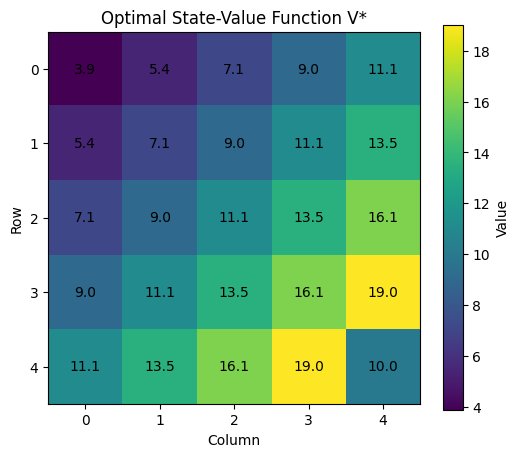

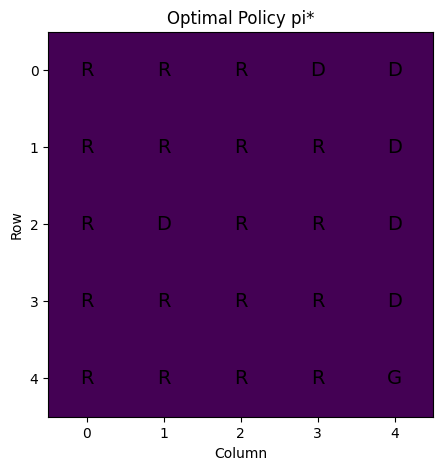

In [5]:
# Simple figures for value function and policy
plt.figure(figsize=(6, 5))
plt.imshow(value_table.values.astype(float))
plt.title("Optimal State-Value Function V*")
plt.colorbar(label="Value")
for r in range(5):
    for c in range(5):
        plt.text(c, r, f"{value_table.iloc[r,c]:.1f}", ha="center", va="center")
plt.xticks(range(5)); plt.yticks(range(5)); plt.xlabel("Column"); plt.ylabel("Row")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(np.zeros((5,5)))
plt.title("Optimal Policy pi*")
for r in range(5):
    for c in range(5):
        plt.text(c, r, policy_table.iloc[r,c], ha="center", va="center", fontsize=14)
plt.xticks(range(5)); plt.yticks(range(5)); plt.xlabel("Column"); plt.ylabel("Row")
plt.show()

### Problem 3 Comparison and Complexity

Both standard and in-place value iteration reach the same optimal values and policy, up to rounding. Standard value iteration is easier to reason about because every state in one sweep uses the previous sweep's values. In-place value iteration often needs fewer sweeps because new values are reused immediately.

For each sweep, both algorithms evaluate every state and every action, so the time complexity per sweep is:

$$O(|S||A|)$$

The memory complexity is slightly different. Standard value iteration stores old and new value tables, so it uses about $O(2|S|)$ value storage. In-place value iteration uses one value table, so it uses $O(|S|)$ value storage.

### Talking Points

**A. Key RL feature:** The key feature is the Bellman optimality backup, which estimates the best long-term return from each state.

**B. Implementation/testing challenge:** A challenge was confirming that synchronous and in-place updates converge to the same result even though the intermediate updates differ.

**C. Why this is RL:** The algorithm estimates value functions and extracts a policy from reward-based interaction dynamics. It is not classification or regression because the goal is to find an action policy that maximizes discounted return.

## Problem 4 - Off-Policy Monte Carlo with Importance Sampling

This problem uses the same 5x5 gridworld as Problem 3. The behavior policy is random and explores all actions. The target policy is greedy and is improved from action-value estimates. Weighted importance sampling corrects for the difference between the behavior policy and the target policy.

The return is calculated backward from each episode:

$$G_t = R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+...$$

Importance sampling ratio:

$$W = \prod rac{\pi(A_t|S_t)}{b(A_t|S_t)}$$

Because the target policy is greedy and deterministic, the backward update stops when an episode action does not match the current greedy target action.

In [6]:
mc = OffPolicyMonteCarloAgent(env, gamma=GAMMA, episodes=20000, seed=42)
V_mc, pi_mc = mc.run()

print("Monte Carlo estimated value function:")
print_grid(env.values_as_grid(V_mc))
print("\nMonte Carlo greedy target policy:")
for row in env.policy_as_grid({s: arrow(a) for s, a in pi_mc.items()}):
    print(row)

mc_table = pd.DataFrame(env.values_as_grid(V_mc), index=[f"row {i}" for i in range(5)], columns=[f"col {i}" for i in range(5)])
vi_table = pd.DataFrame(env.values_as_grid(V_vi), index=[f"row {i}" for i in range(5)], columns=[f"col {i}" for i in range(5)])
abs_diff = (vi_table - mc_table).abs()

display(mc_table.round(2))
display(abs_diff.round(2))

method_compare = pd.DataFrame({
    "Method": ["Value Iteration", "Off-Policy Monte Carlo"],
    "Iterations or Episodes": [vi.iterations, mc.episodes],
    "Optimization Time Seconds": [vi.optimization_time, mc.optimization_time],
    "Update Type": ["Bellman full backup", "Sample returns with weighted importance sampling"],
    "Complexity Comment": ["O(iterations * |S| * |A|)", "O(episodes * average episode length)"]
})
method_compare

2026-06-12 13:50:22,578 | INFO | Starting off-policy MC: gamma=0.9 episodes=20000


2026-06-12 13:50:22,908 | INFO | MC episode=2000/20000


2026-06-12 13:50:23,288 | INFO | MC episode=4000/20000


2026-06-12 13:50:23,683 | INFO | MC episode=6000/20000


2026-06-12 13:50:24,036 | INFO | MC episode=8000/20000


...

2026-06-12 13:50:26,077 | INFO | Finished MC episodes=20000 time=3.496295


Monte Carlo estimated value function:
  -0.44	   0.60	   1.70	   3.01	   4.42
   0.59	   1.60	   2.97	   4.44	   6.09
   1.72	   2.97	   4.48	   6.10	   7.93
   3.00	   4.47	   6.11	   7.94	  10.00
   4.42	   6.03	   7.91	  10.00	  10.00

Monte Carlo greedy target policy:
['R', 'R', 'R', 'D', 'D']
['D', 'R', 'R', 'D', 'D']
['R', 'D', 'D', 'D', 'D']
['R', 'D', 'R', 'R', 'D']
['R', 'R', 'R', 'R', 'G']


,col 0,col 1,col 2,col 3,col 4
row 0,-0.44,0.60,1.70,3.01,4.42
row 1,0.59,1.60,2.97,4.44,6.09
row 2,1.72,2.97,4.48,6.10,7.93
row 3,3.00,4.47,6.11,7.94,10.00
row 4,4.42,6.03,7.91,10.00,10.00


,col 0,col 1,col 2,col 3,col 4
row 0,4.31,4.81,5.42,6.02,6.72
row 1,4.82,5.52,6.06,6.70,7.40
row 2,5.41,6.06,6.66,7.39,8.17
row 3,6.02,6.67,7.38,8.16,9.00
row 4,6.72,7.46,8.19,9.00,0.00


,Method,Iterations or Episodes,Optimization Time Seconds,Update Type,Complexity Comment
0,Value Iteration,10,0.021765,Bellman full backup,O(iterations * |S| * |A|)
1,Off-Policy Monte Carlo,20000,3.496295,Sample returns with weighted importance sampling,O(episodes * average episode length)


### Problem 4 Comparison and Complexity

Value iteration is model-based dynamic programming. It uses the known transition and reward model to update all states systematically. It usually converges quickly in this small deterministic gridworld.

Off-policy Monte Carlo is sample-based. It learns from complete episodes generated by a random behavior policy, then uses importance sampling to estimate values for a greedy target policy. It may require many episodes because random exploration does not always reach the goal efficiently. Its estimates can also have higher variance than value iteration.

Complexity comparison:

- Value iteration: $O(K|S||A|)$ where K is the number of sweeps.
- Monte Carlo: $O(NT)$ where N is the number of episodes and T is the average episode length.

### Talking Points

**A. Key RL feature:** The key feature is off-policy learning. The behavior policy explores randomly, while the target policy is greedy and improved using weighted importance sampling.

**B. Implementation/testing challenge:** The main challenge is avoiding infinite episodes. The implementation uses a maximum episode length to keep training stable and reproducible.

**C. Why this is RL:** Monte Carlo learns values from rewards collected through episodes. It uses states, actions, rewards, returns, behavior policy, target policy, and policy improvement. This matches Sutton and Barto's Monte Carlo control framework.

## Final Notes

The notebook implemented all four assignment problems using one integrated workflow. It includes manual calculations for Problem 2, object-oriented source code, value iteration, in-place value iteration, off-policy Monte Carlo with importance sampling, logging, tables, and figures. The required one-page PDF should contain the public GitHub repository URL ending in `.git`.